In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import collections
import random
import pandas as pd
import datetime
import scipy as sci
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import torch



In [2]:
### define functions for numerical solution ###

N=40 #number of agents
v0=2

lambda1 = 1.999E-01
lambda2 = -1.345E-01
lambda3 = -1.015E-01
lambda4 = 1.146E-01
power1 = -9.288E-02
power2 = 1.826E-01
power3 = 1.322E-01

lambda1_v = -1.026E-01
lambda2_v = -3.282E-01
lambda3_v = -1.597E-01
lambda4_v = 4.405E-01
power1_v = -2.314E-01
power2_v = -3.216E-01
power3_v = -2.862E-01
int_range = 2


def obstacle_interaction(pos, margin=1.0):
    F = np.zeros(2)
    for i, center in enumerate(obstacle_positions):
        r_o = obstacle_radii[i]
        diff = pos - center
        dist = np.linalg.norm(diff)
        d = dist - r_o  # Distance from obstacle boundary (center distance - radius)

        if d < margin:
            F_io_dir = diff / dist          # Unit vector indicating direction
            F += F_io_dir / (d**2)          # Magnitude: inversely proportional to the square of the distance

    return F


def total_infer_x(s, i):
    n_array = np.array(n)
    self_index = np.repeat(i, n - 1)
    others_index = list(range(n))
    others_index.remove(i)

    # Agent-agent interaction
    x1 = np.take(s, self_index)
    y1 = np.take(s, self_index + n_array)
    x2 = np.take(s, others_index)
    y2 = np.take(s, others_index + n_array)
    dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

    vi_x = np.take(s, 2*n_array + self_index)
    vi_y = np.take(s, 3*n_array + self_index)
    vj_x = np.take(s, 2*n_array + others_index)
    vj_y = np.take(s, 3*n_array + others_index)
    vel_rel = np.sqrt((vi_x - vj_x)**2 + (vi_y - vj_y)**2)

    local_dist_func = np.heaviside(int_range - dist, 1)

    F_int_x = (x1 - x2)/dist * (lambda1*(dist**power1) + lambda2*(dist**power2) + lambda3*(dist**power3) + lambda4) + \
              (vi_x - vj_x)/vel_rel * (lambda1_v*(dist**power1_v) + lambda2_v*(dist**power2_v) + lambda3_v*(dist**power3_v) + lambda4_v) * local_dist_func

    total_interaction_x = sum(F_int_x)

    # Self propulsion
    v_i_x = s[2*n + i]
    v_i_y = s[3*n + i]
    v_i_mag = np.sqrt(v_i_x**2 + v_i_y**2)
    self_propel_x = (v_i_x / v_i_mag) * (v0 - v_i_mag)

    # Obstacle repulsion
    pos_i = np.array([s[i], s[i + n]])
    obs_force_x = obstacle_interaction(pos_i, obs_margin)[0]

    return self_propel_x + total_interaction_x + obs_force_x


def total_infer_y(s, i):
    n_array = np.array(n)
    self_index = np.repeat(i, n - 1)
    others_index = list(range(n))
    others_index.remove(i)

    # Agent-agent interaction
    x1 = np.take(s, self_index)
    y1 = np.take(s, self_index + n_array)
    x2 = np.take(s, others_index)
    y2 = np.take(s, others_index + n_array)
    dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

    vi_x = np.take(s, 2*n_array + self_index)
    vi_y = np.take(s, 3*n_array + self_index)
    vj_x = np.take(s, 2*n_array + others_index)
    vj_y = np.take(s, 3*n_array + others_index)
    vel_rel = np.sqrt((vi_x - vj_x)**2 + (vi_y - vj_y)**2)

    local_dist_func = np.heaviside(int_range - dist, 1)

    F_int_y = (y1 - y2)/dist * (lambda1*(dist**power1) + lambda2*(dist**power2) + lambda3*(dist**power3) + lambda4) + \
              (vi_y - vj_y)/vel_rel * (lambda1_v*(dist**power1_v) + lambda2_v*(dist**power2_v) + lambda3_v*(dist**power3_v) + lambda4_v) * local_dist_func

    total_interaction_y = sum(F_int_y)

    # Self propulsion
    v_i_x = s[2*n + i]
    v_i_y = s[3*n + i]
    v_i_mag = np.sqrt(v_i_x**2 + v_i_y**2)
    self_propel_y = (v_i_y / v_i_mag) * (v0 - v_i_mag)

    # Obstacle repulsion
    pos_i = np.array([s[i], s[i + n]])
    obs_force_y = obstacle_interaction(pos_i, obs_margin)[1]

    return self_propel_y + total_interaction_y + obs_force_y



def F_infer_ivp(t,s):
    return np.concatenate((s[2*n:3*n],s[3*n:4*n],\
                           [total_infer_x(s,i) for i in range(n)]+np.random.normal(0,10,size=n), 
                           [total_infer_y(s,i) for i in range(n)]+np.random.normal(0,10,size=n)))


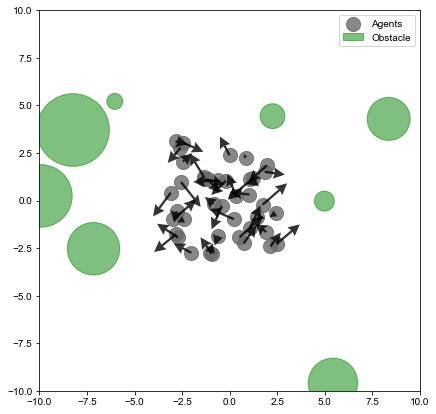

In [3]:
plt.rc('font', size=20, family='Arial')

########## Initial condition (with obstacle avoidance, based on field size) ##########

position_list_x = []
position_list_y = []
velocity_list_x = []
velocity_list_y = []

random.seed(101)

field = 40**0.5 / 2

for i in range(40):
    position_list_x.append(random.uniform(-field, field))
    position_list_y.append(random.uniform(-field, field))
    velocity_list_x.append(random.uniform(-2.0, 2.0))
    velocity_list_y.append(random.uniform(-2.0, 2.0))

nodes_np = np.array([position_list_x, position_list_y, velocity_list_x, velocity_list_y], dtype=np.float32)

s0 = nodes_np.reshape(-1)
n = nodes_np.shape[1]

########## Define the obstacles ##########

num_obstacles = 8
obs_margin = 1.0
arena_size = 10
np.random.seed(10)
range_init = field

obstacle_positions = []
obstacle_radii = []

def is_outside_agent_area(x, y, margin=range_init):
    return abs(x) > margin or abs(y) > margin  # Valid if either coordinate is outside the margin

while len(obstacle_positions) < num_obstacles:
    x, y = np.random.uniform(-arena_size, arena_size, size=2)
    if is_outside_agent_area(x, y):
        obstacle_positions.append([x, y])
        obstacle_radii.append(np.random.uniform(0.1, 2.0))

obstacle_positions = np.array(obstacle_positions)
obstacle_radii = np.array(obstacle_radii)

########## Visualization of Initial Positions and Velocities ##########

# Define colors
agent_color = np.array([105./255, 105./255, 105./255, 0.8])
init_color = np.array([0., 0., 0.])  # Default color when no rotation color is provided

fig, ax = plt.subplots(figsize=(7, 7))

# Initial agent positions
ax.scatter(position_list_x, position_list_y, color=agent_color, s=200, label='Agents')

# Velocity vectors (quiver)
origin = np.array([position_list_x, position_list_y])
velocity_array = np.array([velocity_list_x, velocity_list_y])
quiver_color = [np.append(init_color, 0.8) for _ in range(N)]

plt.quiver(*origin, velocity_array[0], velocity_array[1],
           scale_units='xy', angles='xy', color=quiver_color,
           scale=1.5, width=0.006, headwidth=5, zorder=2)

# Visualize obstacles
for pos, r in zip(obstacle_positions, obstacle_radii):
    circle = plt.Circle(pos, r, color='green', alpha=0.5, label='Obstacle')
    ax.add_patch(circle)

# Visualization settings
ax.set_aspect('equal')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

# Legend (remove duplicates)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.show()


In [4]:
dt=0.1
T=50
t=np.arange(0,T+dt,dt)
print(t.shape)

(501,)


In [5]:
dt=0.1
T=50
t=np.arange(0,T+dt,dt)

solution=solve_ivp(F_infer_ivp,[0,T],s0, method='RK45', max_step= 0.01, t_eval=t)

print(solution)

  message: 'The solver successfully reached the end of the integration interval.'
     nfev: 1143518
     njev: 0
      nlu: 0
      sol: None
   status: 0
  success: True
        t: array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
       12.1, 1

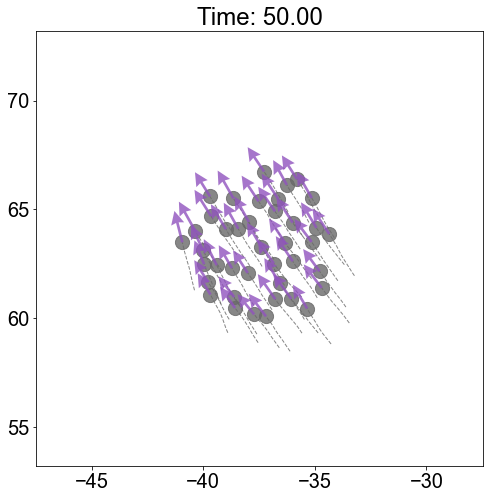

In [6]:
import matplotlib.animation as animation

solution_plot = np.transpose(solution.y)

plt.rc('font', family='Arial', size=20)
speed = 1
t_plot = np.arange(0, T + dt * speed, dt * speed)
h = solution_plot[:, 0:2*n]
velocity = solution_plot[:, 2*n:4*n]

fig = plt.figure(figsize=(8, 8))
ax = plt.axes()
cmap1 = plt.cm.get_cmap('jet', 40)

tail_length = 10

############################### Order Parameter Calculation ###############################
velocity_x = velocity[:, 0:n]
velocity_y = velocity[:, n:]
center_x = np.mean(h[:, 0:n], axis=1, keepdims=True)
center_y = np.mean(h[:, n:], axis=1, keepdims=True)
r_x, r_y = h[:, 0:n] - center_x, h[:, n:] - center_y

r_mag = np.sqrt(np.square(r_x) + np.square(r_y))
vel_mag = np.sqrt(np.square(velocity_x) + np.square(velocity_y))  # Magnitude of individual velocity vectors
vel_mag_sum = np.sum(vel_mag, axis=1)

vel_x_sum = np.sum(velocity_x, axis=1)
vel_y_sum = np.sum(velocity_y, axis=1)

vel_vec_mag = np.sqrt(np.square(vel_x_sum) + np.square(vel_y_sum))  # Magnitude of total velocity vector

order_para = vel_vec_mag / vel_mag_sum

ang_mom = r_x * velocity_y - r_y * velocity_x

denom = np.sum(r_mag * vel_mag, axis=1)
ang_mom_sum = np.abs(np.sum(ang_mom, axis=1))
ang_mom_abs = np.sum(np.abs(ang_mom), axis=1)

order_para_rot = ang_mom_sum / denom
order_para_rot_abs = ang_mom_abs / denom

############################### Visualization Colors ###############################
init_color = np.array([0., 0., 0.])
cw_color = np.array([0., 100., 250.])
ccw_color = np.array([240., 84., 0.])
flock_color = np.array([145., 84., 192.])
agent_color = np.array([105./255, 105./255, 105./255, 0.8])

############################### Animation Function ###############################

def animate(i):
    window = 10
    ax.clear()
    
    # Add obstacles
    for k in range(len(obstacle_positions)):
        obstacle_circle = plt.Circle(
            obstacle_positions[k],
            obstacle_radii[k],
            color='green',
            alpha=0.5,
            zorder=1
        )
        ax.add_patch(obstacle_circle)

    # Agent positions
    plt.scatter(h[i*speed, 0:n], h[i*speed, n:], color=agent_color, s=200, zorder=0)

    # Tail trajectories
    for j in range(n):
        ax.plot(h[i*speed - tail_length:i*speed+1, j],
                h[i*speed - tail_length:i*speed+1, n+j],
                '--', c=agent_color, lw=1, ms=1)
    
    # Velocity arrow coloring based on order parameter
    rot_color = []
    for ii in range(len(ang_mom[i*speed, :])):
        if order_para[i*speed] > 0.7:
            # Interpolate flock color if order is high
            rot_color.append(np.append(flock_color * (order_para[i*speed] - 0.7) / 0.3 / 255, [0.8]))
        else:
            rot_color.append(np.append(init_color, [0.8]))
    
    # Velocity vector arrows
    origin = np.array([h[i*speed, 0:n], h[i*speed, n:]])
    plt.quiver(*origin, velocity[i*speed, 0:n], velocity[i*speed, n:], 
               scale_units='xy', angles='xy', color=rot_color,
               scale=1.5, width=0.006, headwidth=5, zorder=2)

    # Centered view window
    center_x_i = np.mean(h[i*speed, 0:n])
    center_y_i = np.mean(h[i*speed, n:])
    
    ax.set_title('Time: {:.2f}'.format(t[i*speed]))
    ax.set_xticks(np.arange(-100, 100, 5))
    ax.set_yticks(np.arange(-100, 100, 5))
    ax.set_xlim(center_x_i - window, center_x_i + window)
    ax.set_ylim(center_y_i - window, center_y_i + window)

# Run animation
anim = animation.FuncAnimation(fig, animate, frames=len(t_plot))

from IPython.display import HTML
HTML(anim.to_html5_video())
